In [1]:
import importlib.util, subprocess, sys

required = {"gensim": "gensim", "kiwipiepy": "kiwipiepy", "pandas": "pandas", "torch": "torch"}
missing = [package for module, package in required.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

import platform, numpy as np, pandas as pd, torch, gensim, kiwipiepy
print("Python", platform.python_version())
print("torch", torch.__version__, "| GPU:", torch.cuda.is_available())
print("gensim", gensim.__version__)
print("kiwipiepy", kiwipiepy.__version__)

Python 3.12.14
torch 2.14.0+cpu | GPU: False
gensim 4.4.0
kiwipiepy 0.23.2


# 3주차 과제: 분산 표현과 SGNS

Steam 리뷰 말뭉치에서 CBOW와 Skip-gram, 창 크기, 부정 표본 수의 영향을 비교한다. 형태소 분석기는 Kiwi로 고정했다. gensim 실험은 리뷰 100,000건 전체를 사용한다. 직접 구현한 SGNS와 SPPMI 비교는 실행 시간과 행렬 크기를 맞추기 위해 고정 시드로 선택한 리뷰 20,000건과 동일한 상위 2,000개 어휘를 사용한다.

In [2]:
from pathlib import Path
import urllib.request
from collections import Counter
from kiwipiepy import Kiwi

CORPUS_URL = "https://raw.githubusercontent.com/bab2min/corpus/master/sentiment/steam.txt"
CORPUS_PATH = "/content/corpus.txt"
corpus_path = Path(CORPUS_PATH)
corpus_path.parent.mkdir(parents=True, exist_ok=True)
if not corpus_path.exists():
    urllib.request.urlretrieve(CORPUS_URL, CORPUS_PATH)

lines, labels = [], []
for line in corpus_path.read_text(encoding="utf-8").splitlines():
    label, text = line.split("\t", 1)
    if text.strip():
        labels.append(int(label))
        lines.append(text.strip())

kiwi = Kiwi()
analyses = kiwi.analyze(lines, top_n=1)
sentences, nouns = [], Counter()
for result in analyses:
    tokens = result[0][0]
    sentences.append([t.form for t in tokens])
    nouns.update(t.form for t in tokens if t.tag == "NNG" and len(t.form) > 1)

print("파일:", CORPUS_PATH)
print(f"리뷰 {len(lines):,}개, 형태소 토큰 {sum(map(len, sentences)):,}개")
print("고빈도 일반명사:", nouns.most_common(10))

파일: /content/corpus.txt
리뷰 100,000개, 형태소 토큰 2,561,515개
고빈도 일반명사: [('게임', 46336), ('플레이', 6671), ('재미', 4899), ('추천', 4887), ('사람', 4865), ('생각', 4330), ('스토리', 4233), ('시간', 3927), ('한글', 3654), ('그래픽', 3119)]


## 1. CBOW와 Skip-gram 유사도 비교

두 모델은 `window=5`, `negative=5`, `vector_size=100`, `epochs=10`으로 맞췄다. 고빈도 일반명사는 `게임`, `스토리`, `그래픽`, 저빈도 일반명사는 전체 말뭉치에서 5~10회 나온 `맵디자인`, `리듬감`, `댕댕이`를 골랐다.

In [3]:
from gensim.models import Word2Vec

common = dict(vector_size=100, window=5, min_count=3, negative=5,
              sample=1e-3, epochs=10, seed=42, workers=1)
cbow = Word2Vec(sentences, sg=0, **common)
sg5 = Word2Vec(sentences, sg=1, **common)

high_queries = ["게임", "스토리", "그래픽"]
low_queries = ["맵디자인", "리듬감", "댕댕이"]
rows = []
for group, queries in [("고빈도", high_queries), ("저빈도", low_queries)]:
    for query in queries:
        for model_name, model in [("CBOW", cbow), ("Skip-gram", sg5)]:
            for rank, (word, sim) in enumerate(model.wv.most_similar(query, topn=5), 1):
                rows.append({"빈도 구분": group, "질의어": query, "빈도": nouns[query],
                             "구조": model_name, "순위": rank, "이웃": word,
                             "유사도": round(float(sim), 4)})
similarity_table = pd.DataFrame(rows)
display(similarity_table)

,빈도 구분,질의어,빈도,구조,순위,이웃,유사도
0,고빈도,게임,46336,CBOW,1,작품,0.5464
1,고빈도,게임,46336,CBOW,2,겜,0.5194
2,고빈도,게임,46336,CBOW,3,것,0.5110
3,고빈도,게임,46336,CBOW,4,발상,0.4506
4,고빈도,게임,46336,CBOW,5,장르,0.4488
5,고빈도,게임,46336,Skip-gram,1,케주얼,0.7370
6,고빈도,게임,46336,Skip-gram,2,겜,0.6804
7,고빈도,게임,46336,Skip-gram,3,정적,0.6638
8,고빈도,게임,46336,Skip-gram,4,현존,0.6507
9,고빈도,게임,46336,Skip-gram,5,대체재,0.6488


### 해석

고빈도어에서는 두 구조 모두 비교적 안정적이었다. `스토리`는 내용·연출·전개가, `그래픽`은 사운드·렌더링·색감 같은 게임 구성 요소가 가까웠다. 저빈도어는 결과가 일정하지 않았다. `맵디자인`의 Skip-gram 이웃에는 `내러티브`, `룻`처럼 게임 설계 문맥과 연결되는 단어가 일부 있었고 CBOW보다 조금 더 그럴듯했다. 반면 `리듬감`과 `댕댕이`는 두 구조 모두 관련 없는 고유명사나 한 문장에서 우연히 함께 나온 표현이 많았다.

Skip-gram은 하나의 중심 단어에서 창 안의 문맥 단어마다 학습 쌍을 만들기 때문에 저빈도어가 등장한 한 위치에서도 여러 번 갱신된다. CBOW는 주변 단어 벡터를 평균해 중심 단어 하나를 맞히므로 위치마다 한 번 갱신되고 개별 문맥의 특징도 평균된다. 이번 결과는 Skip-gram의 장점이 일부 보이지만, 5~10회의 관측만으로는 어느 구조도 안정적인 의미 이웃을 보장하지 않는다는 점도 보여 준다.

## 2. 창 크기 실험

구조는 Skip-gram으로 고정하고 `window`만 2, 5, 10으로 바꿨다. 질의어는 세 모델에 공통으로 존재하는 `스토리`, `그래픽`, `버그`다.

In [4]:
window_models = {5: sg5}
for window in [2, 10]:
    window_models[window] = Word2Vec(
        sentences, sg=1, vector_size=100, window=window, min_count=3,
        negative=5, sample=1e-3, epochs=10, seed=42, workers=1
    )

window_queries = ["스토리", "그래픽", "버그"]
window_rows = []
for query in window_queries:
    for window in [2, 5, 10]:
        neighbors = window_models[window].wv.most_similar(query, topn=5)
        window_rows.append({"질의어": query, "window": window,
                            "이웃 5개": ", ".join(w for w, _ in neighbors)})
window_table = pd.DataFrame(window_rows)
display(window_table)

,질의어,window,이웃 5개
0,스토리,2,"시나리오, 내용, 몰입도, 결말, 영상미"
1,스토리,5,"연출, 전개, 내용, 스토리텔링, 탄탄"
2,스토리,10,"연출, 전개, 급작스럽, 용두사미, 탄탄"
3,그래픽,2,"퀄, 모델링, 타격감, 모션, 음향"
4,그래픽,5,"사운드, 렌더링, 음향, 광원, 아트웍"
5,그래픽,10,"사운드, 광원, 투박, 미니어처, 때깔"
6,버그,2,"오류, 크래쉬, 크래시, 잔버그, 버그만"
7,버그,5,"오류, 크래쉬, 프리즈, 잔버그, 프리징"
8,버그,10,"오류, 프리즈, PM, 현상, 정떨어지"


### 해석

`스토리`는 window 2에서 `시나리오`, `내용`, `결말`처럼 비교적 대체 가능하거나 직접적인 구성 요소가 나왔고, window 10에서는 `용두사미`, `탄탄`, `급작스럽`처럼 스토리를 평가하는 주제 표현이 섞였다. `그래픽`도 window 2의 `모델링`, `모션`, `타격감`에서 window 10의 `사운드`, `광원`, `미니어처`, `때깔`로 범위가 넓어졌다. 두 질의어는 창이 커지며 같은 리뷰에서 함께 언급되는 주제어가 늘었다고 볼 수 있다.

`버그`는 window 2·5·10 모두 `오류`, `크래쉬`, `프리즈`, `팅김` 계열이 중심이라 이동을 분명히 판단하기 어렵다. 오류 관련 단어들이 가까운 위치에서도 함께 나오고 리뷰 전체의 주제도 이루기 때문이다. 큰 창이 항상 대체 관계를 주제 관계로 바꾸는 것은 아니며 말뭉치의 문장 길이와 반복 표현에 따라 변화가 작을 수 있다.

## 3. SGNS 손실 곡선

고정 시드로 선택한 리뷰 20,000건에서 상위 2,000개 형태소만 남기고 `window=5`의 학습 쌍을 만들었다. 세 실험은 같은 학습 쌍, 초기화, 순서를 사용하고 부정 표본 수 (K)만 1, 5, 20으로 바꿨다.

In [5]:
import random, math
import torch.nn as nn
import torch.nn.functional as F

rng = np.random.default_rng(42)
sample_indices = np.sort(rng.choice(len(sentences), size=20_000, replace=False))
sample_sentences = [sentences[i] for i in sample_indices]
sample_counts = Counter(w for s in sample_sentences for w in s)
vocab = [w for w, _ in sample_counts.most_common(2_000)]
w2i = {w: i for i, w in enumerate(vocab)}
V = len(vocab)
ids = [[w2i[w] for w in s if w in w2i] for s in sample_sentences]

WINDOW = 5
pairs = [(s[i], s[j]) for s in ids for i in range(len(s))
         for j in range(max(0, i-WINDOW), min(len(s), i+WINDOW+1)) if j != i]
pair_data = torch.tensor(pairs, dtype=torch.long)
unigram = torch.tensor([sample_counts[w] for w in vocab], dtype=torch.float32)
noise = unigram.pow(0.75); noise /= noise.sum()
print(f"표본 리뷰 {len(sample_sentences):,}개, 어휘 {V:,}개, 학습 쌍 {len(pair_data):,}개")

표본 리뷰 20,000개, 어휘 2,000개, 학습 쌍 4,107,214개


,K,시점,평균 손실,(K+1)log2
0,1,초기,1.3863,1.3863
1,1,epoch 1,1.2900,
2,1,epoch 2,1.2682,
3,1,epoch 3,1.2608,
4,5,초기,4.1589,4.1589
5,5,epoch 1,2.5512,
6,5,epoch 2,2.4891,
7,5,epoch 3,2.4770,
8,20,초기,14.5561,14.5561
9,20,epoch 1,3.9771,


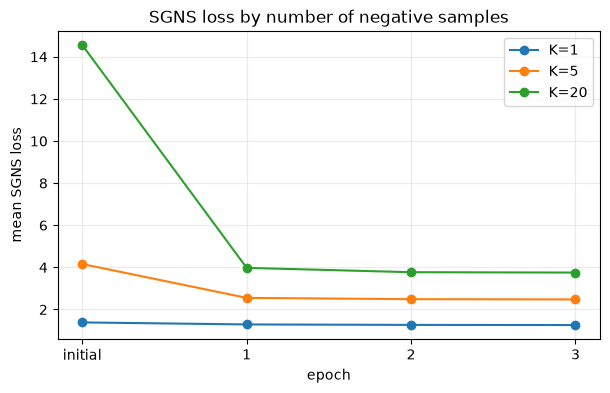

In [6]:
class SGNS(nn.Module):
    def __init__(self, vocab_size, dim=100):
        super().__init__()
        self.v = nn.Embedding(vocab_size, dim)
        self.u = nn.Embedding(vocab_size, dim)
        nn.init.uniform_(self.v.weight, -0.5 / dim, 0.5 / dim)
        nn.init.zeros_(self.u.weight)

    def forward(self, center, context, negatives):
        vc = self.v(center)
        uo = self.u(context)
        uk = self.u(negatives)
        pos = F.logsigmoid((uo * vc).sum(-1))
        neg = F.logsigmoid(-(uk @ vc.unsqueeze(-1)).squeeze(-1)).sum(-1)
        return -(pos + neg).mean()

device = "cuda" if torch.cuda.is_available() else "cpu"
BATCH, EPOCHS = 4096, 3

def train_sgns(K):
    torch.manual_seed(42)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(42)
    model = SGNS(V, 100).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    histories = []
    probe = pair_data[:BATCH]
    with torch.no_grad():
        neg = torch.multinomial(noise, len(probe)*K, replacement=True).view(len(probe), K).to(device)
        initial = model(probe[:,0].to(device), probe[:,1].to(device), neg).item()
    histories.append(initial)
    generator = torch.Generator().manual_seed(42)
    for epoch in range(EPOCHS):
        perm = torch.randperm(len(pair_data), generator=generator)
        total = 0.0
        for start in range(0, len(pair_data), BATCH):
            batch = pair_data[perm[start:start+BATCH]]
            center, context = batch[:,0].to(device), batch[:,1].to(device)
            negatives = torch.multinomial(noise, len(batch)*K, replacement=True).view(len(batch),K).to(device)
            loss = model(center, context, negatives)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            total += loss.item()*len(batch)
        histories.append(total/len(pair_data))
    return model.cpu(), histories

sgns_models, loss_rows = {}, []
for K in [1, 5, 20]:
    model, history = train_sgns(K)
    sgns_models[K] = model
    for epoch, loss in enumerate(history):
        loss_rows.append({"K": K, "시점": "초기" if epoch == 0 else f"epoch {epoch}",
                          "평균 손실": round(loss, 4),
                          "(K+1)log2": round((K+1)*math.log(2), 4) if epoch == 0 else ""})
loss_table = pd.DataFrame(loss_rows)
display(loss_table)

import matplotlib.pyplot as plt
plt.figure(figsize=(7, 4))
for K in [1, 5, 20]:
    values = loss_table.loc[loss_table["K"] == K, "평균 손실"].astype(float).tolist()
    plt.plot(range(4), values, marker="o", label=f"K={K}")
plt.xticks(range(4), ["initial", "1", "2", "3"])
plt.xlabel("epoch")
plt.ylabel("mean SGNS loss")
plt.title("SGNS loss by number of negative samples")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

### 초기 손실과 K별 비교

초기에는 문맥 임베딩 (u)가 0이므로 모든 내적이 0이다. 따라서 양성 항과 각 부정 항에서 (-\log\sigma(0)=-\log(1/2)=\log 2)가 나온다. 양성 항 1개와 부정 항 (K)개의 합은 ((K+1)\log 2)다. (K)가 커지면 한 학습 사례의 손실에 더해지는 부정 항 자체가 많아진다. 그러므로 K가 다른 실험의 원손실 크기를 그대로 비교하면 모델의 구분 능력보다 항의 개수 차이를 함께 비교하게 된다. 감소율이나 항당 손실, 또는 같은 K 안에서의 변화로 해석해야 한다.

## 도전 과제: SGNS와 SPPMI+SVD

위 SGNS 실험과 같은 20,000개 리뷰, 상위 2,000개 어휘, `window=5` 공기쌍을 사용한다. (K=5)로 두고 (\max(PMI-\log K,0))를 계산한 뒤 `torch.linalg.svd`로 100차원 벡터를 만든다.

In [7]:
from scipy import sparse

pair_np = pair_data.numpy()
cooc = sparse.coo_matrix(
    (np.ones(len(pair_np), dtype=np.float32), (pair_np[:,0], pair_np[:,1])),
    shape=(V,V)
).tocsr()
cooc.sum_duplicates()
rows, cols = cooc.nonzero()
values = cooc.data.astype(np.float64)
row_sum = np.asarray(cooc.sum(axis=1)).ravel()
col_sum = np.asarray(cooc.sum(axis=0)).ravel()
total = values.sum()
shifted = np.log(values*total/(row_sum[rows]*col_sum[cols])) - math.log(5)
positive = shifted > 0
sppmi = sparse.csr_matrix((shifted[positive].astype(np.float32),
                           (rows[positive], cols[positive])), shape=(V,V))
sppmi_dense = torch.from_numpy(sppmi.toarray())
U, S, Vh = torch.linalg.svd(sppmi_dense, full_matrices=False)
sppmi_emb = U[:,:100] * S[:100].sqrt()

sgns_emb = sgns_models[5].v.weight.detach()
sgns_emb = F.normalize(sgns_emb, dim=1)
sppmi_emb = F.normalize(sppmi_emb, dim=1)

def nearest(emb, word, n=5):
    idx = w2i[word]
    sims = emb @ emb[idx]
    top = sims.topk(n+1).indices.tolist()
    return [vocab[i] for i in top if i != idx][:n]

challenge_queries = ["게임", "스토리", "그래픽", "버그", "음악"]
challenge_rows = []
for query in challenge_queries:
    a = nearest(sgns_emb, query)
    b = nearest(sppmi_emb, query)
    challenge_rows.append({"질의어": query, "SGNS 이웃": ", ".join(a),
                           "SPPMI+SVD 이웃": ", ".join(b),
                           "공통 이웃 수": len(set(a)&set(b))})
challenge_table = pd.DataFrame(challenge_rows)
print("SPPMI 비영 원소:", f"{sppmi.nnz:,}", "SVD 벡터:", tuple(sppmi_emb.shape))
display(challenge_table)

SPPMI 비영 원소: 152,926 SVD 벡터: (2000, 100)


,질의어,SGNS 이웃,SPPMI+SVD 이웃,공통 이웃 수
0,게임,"형식, 작품, 심심풀이, ., 겜","리듬, 평범, 액션, VR, 곡",0
1,스토리,"연출, BGM, 퀄리티, 음악, 그래픽","연출, 음악, ★★★★☆, 10/10, 잔잔",2
2,그래픽,"도트, 타격감, 분위기, 뛰어나, 사운드","음악, 연출, 아기자기, 배경, BGM",0
3,버그,"오류, 팅김, 현상, 팅, 튕기","오류, 팅김, 팅, 현상, 에러",4
4,음악,"연출, BGM, 스토리, 비주얼, 도트","연출, ★★★★☆, 10/10, 스토리, 평점",2


### 비교 해석

공통 이웃 수는 `게임` 0개, `스토리` 2개, `그래픽` 0개, `버그` 4개, `음악` 2개였다. `버그`는 두 방법 모두 `오류`, `팅김`, `현상`, `팅`을 찾아 동치가 가장 분명하게 나타났다. `스토리`와 `음악`도 `연출`, `음악`, `스토리`를 일부 공유했다. 반면 `게임`과 `그래픽`은 공통 이웃이 없었다. 두 방법이 같은 공기 통계를 보더라도 가까운 단어의 세부 순위는 상당히 달랐다.

Levy와 Goldberg의 결과는 차원 제약이 없고 각 단어·문맥 쌍을 독립적으로 최적화할 때 SGNS의 내적이 (PMI-\log K)에 놓인다는 설명이다. 실제 실험에서는 100차원 제약, SGNS의 확률적 최적화와 빈도 가중, SPPMI의 음수 절단, SVD의 제곱오차가 서로 다르다. 이번 결과는 두 방법이 일부 강한 공기 관계를 공유한다는 점에서는 동치를 지지하지만, 최근접 이웃 목록까지 같아지는 강한 형태의 동치는 성립하지 않았다.